# Setting Directories

In [1]:
wd = "/home/manndo/master_dev"
# autodock_poses_dir = wd + "/docking_ready_mgltools/docking"
# diffdock_poses_dir = wd + "/diffdock_results"
# equibind_guided_poses_dir = wd + "/equibind_pocket_guided"
# equibind_exclusion_poses_dir = wd + "/equibind_spatial_exclusion_poses"
# equibind_docked_poses_dir = wd + "/equibind_docked_poses"
# equibind_docked_poses_dir = wd + "/equibind_docked_poses_2"
diffdock_poses_dir_large_ligands = wd + "/diffdock_results/ligands_sdf_large"

# Setting proteins_dir to the path of the Orai proteins directory for PoseBuster Mode "dock"
proteins_dir = wd + "/Orai"

docking_directories = {
    # "autodock": autodock_poses_dir,
    # "diffdock": diffdock_poses_dir,
    # "equibind_guided": equibind_guided_poses_dir,
    # "equibind_exclusion": equibind_exclusion_poses_dir,
    # "equibind_docked_poses": equibind_docked_poses_dir,
    # "equibind_docked_poses": equibind_docked_poses_dir,
    "diffdock": diffdock_poses_dir_large_ligands
}

In [2]:
"""
Overview: Pose Counts by Docking Method and Protein-Ligand Combination
This cell analyzes all docking results directories and creates a summary table.
It iterates over `docking_directories` and filters each directory for poses
based on the docking method key.
"""
import pandas as pd
from pathlib import Path
import re


def count_autodock_poses(poses_dir):
    """Count AutoDock Vina poses from PDBQT files"""
    data = []
    base_path = Path(poses_dir)

    for pdbqt_file in base_path.glob("*_vina_out.pdbqt"):
        stem = pdbqt_file.stem.replace("_vina_out", "")
        parts = stem.split("__")

        if len(parts) == 2:
            protein, ligand = parts

            # Count MODEL entries in PDBQT file
            with open(pdbqt_file, 'r') as f:
                content = f.read()
                pose_count = content.count('MODEL')
                if pose_count == 0:
                    pose_count = 1  # Single pose file without MODEL markers

            data.append({
                "Protein": protein,
                "Ligand": ligand,
                "Poses": pose_count
            })

    return pd.DataFrame(data)


def count_diffdock_poses(poses_dir):
    """Count DiffDock poses from SDF files in subdirectories"""
    data = []
    base_path = Path(poses_dir)

    for subdir in base_path.iterdir():
        if not subdir.is_dir():
            continue
        # Skip helper directories
        if "_ligand__" in subdir.name or subdir.name in ["prepared_proteins", "converted_pdbqt", "prepared_ligands", "Orai"]:
            continue

        parts = subdir.name.split("__")
        if len(parts) == 2:
            ligand, protein = parts

            # Count all SDF files in subdirectory (including complex_* folders)
            pose_count = len(list(subdir.glob("**/*.sdf")))

            if pose_count > 0:
                data.append({
                    "Protein": protein,
                    "Ligand": ligand,
                    "Poses": pose_count
                })

    return pd.DataFrame(data)


def count_equibind_poses(poses_dir):
    """Count EquiBind poses from SDF files, supporting spatial_sites directory structure.

    Handles directories named like:
      {ligand}__{protein}_spatial_sites/site_XX/pose_XX.sdf
    as well as flat directories:
      {ligand}__{protein}/*.sdf
    """
    data = []
    base_path = Path(poses_dir)

    for subdir in base_path.iterdir():
        if not subdir.is_dir():
            continue
        # Skip pymol export/fixed variants for main count
        if "_pymol" in subdir.name:
            continue

        dir_name = subdir.name

        # Handle spatial_sites suffix: strip it to extract the protein name
        is_spatial = dir_name.endswith("_spatial_sites")
        if is_spatial:
            dir_name_clean = dir_name.replace("_spatial_sites", "")
        else:
            dir_name_clean = dir_name

        parts = dir_name_clean.split("__")
        if len(parts) == 2:
            ligand, protein = parts

            # Count SDF files recursively (covers site_XX subdirs and flat layouts)
            pose_count = len(list(subdir.glob("**/*.sdf")))

            if pose_count > 0:
                data.append({
                    "Protein": protein,
                    "Ligand": ligand,
                    "Poses": pose_count
                })

    return pd.DataFrame(data)


# Map docking method keys to their counting functions
POSE_COUNTERS = {
    "autodock": count_autodock_poses,
    "diffdock": count_diffdock_poses,
    "equibind_guided": count_equibind_poses,
    "equibind_exclusion": count_equibind_poses,
    "equibind_docked_poses": count_equibind_poses,
}

# Collect pose counts from all methods defined in docking_directories
print("=" * 100)
print("DOCKING POSES OVERVIEW")
print("=" * 100)
print("\nCollecting pose counts from all docking methods...\n")

method_dfs = {}
for method, poses_dir in docking_directories.items():
    counter_fn = POSE_COUNTERS.get(method)
    if counter_fn is None:
        print(f"  WARNING: No pose counter registered for method '{method}', skipping.")
        continue

    if not Path(poses_dir).exists():
        print(f"  WARNING: Directory not found for '{method}': {poses_dir}, skipping.")
        continue

    df = counter_fn(poses_dir)
    # Rename the Poses column to the method name for merging
    col_name = method.replace(" ", "_").title()
    df = df.rename(columns={"Poses": col_name})
    method_dfs[col_name] = df
    print(f"  {col_name}: {len(df)} protein-ligand combinations")

# Merge all method DataFrames into one table
df_combined = pd.DataFrame()
for col_name, df in method_dfs.items():
    if df_combined.empty:
        df_combined = df
    else:
        df_combined = df_combined.merge(df, on=["Protein", "Ligand"], how="outer")

if not df_combined.empty:
    # Fill NaN with 0 and convert pose count columns to int
    method_cols = [c for c in df_combined.columns if c not in ("Protein", "Ligand")]
    df_combined = df_combined.fillna(0)
    for col in method_cols:
        df_combined[col] = df_combined[col].astype(int)

    # Add total column
    df_combined["Total"] = df_combined[method_cols].sum(axis=1)

    # Sort by protein, then ligand
    df_combined = df_combined.sort_values(["Protein", "Ligand"])

    # Display full table
    print("\n" + "=" * 100)
    print("POSE COUNTS BY PROTEIN-LIGAND COMBINATION")
    print("=" * 100)
    print(df_combined.to_string(index=False))

    # Summary statistics
    print("\n" + "=" * 100)
    print("SUMMARY STATISTICS")
    print("=" * 100)
    print(f"\nTotal unique protein-ligand combinations: {len(df_combined)}")
    print(f"\nTotal poses by method:")
    for col in method_cols:
        print(f"  {col}: {df_combined[col].sum():,} poses")
    print(f"  Combined Total: {df_combined['Total'].sum():,} poses")

    print(f"\nUnique proteins: {df_combined['Protein'].nunique()}")
    print(f"Unique ligands: {df_combined['Ligand'].nunique()}")

    # Breakdown by ligand
    print("\n" + "-" * 100)
    print("POSES BY LIGAND")
    print("-" * 100)
    ligand_summary = df_combined.groupby("Ligand")[method_cols + ["Total"]].sum()
    print(ligand_summary.to_string())

    # Breakdown by protein
    print("\n" + "-" * 100)
    print("POSES BY PROTEIN")
    print("-" * 100)
    protein_summary = df_combined.groupby("Protein")[method_cols + ["Total"]].sum()
    print(protein_summary.to_string())

    # Save to CSV
    output_file = Path(wd + "/posebusters_results") / "pose_counts_overview.csv"
    output_file.parent.mkdir(exist_ok=True)
    df_combined.to_csv(output_file, index=False)
    print(f"\n" + "=" * 100)
    print(f"Table saved to: {output_file}")
    print("=" * 100)

else:
    print("\nNo docking results found!")

DOCKING POSES OVERVIEW


  Diffdock: 1062 protein-ligand combinations

POSE COUNTS BY PROTEIN-LIGAND COMBINATION
                     Protein      Ligand  Diffdock  Total
Orai1WT-MDSnap-Fr300_cleaned   017_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   032_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   04J_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   07J_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   08Y_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   09L_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   0LI_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   0RI_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   0WM_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   0XZ_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   10A_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   115_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   116_ideal        10     10
Orai1WT-MDSnap-Fr300_cleaned   117_ideal        10     10
Orai1WT-MDSnap-Fr

In [3]:
"""
Filter Poses: Keep Only Protein-Ligand Combinations Docked in ALL Methods
==========================================================================
This cell filters the results to include only protein-ligand combinations
that have poses from every docking method defined in `docking_directories`.
"""

# ============================================================================
# POSE COLLECTORS — return list of row dicts for each method
# ============================================================================

def collect_autodock_rows(poses_dir):
    """Collect per-file rows from AutoDock Vina PDBQT outputs."""
    rows = []
    base_path = Path(poses_dir)
    for pdbqt_file in base_path.glob("*_vina_out.pdbqt"):
        stem = pdbqt_file.stem.replace("_vina_out", "")
        parts = stem.split("__")
        if len(parts) == 2:
            protein, ligand = parts
            with open(pdbqt_file, 'r') as f:
                content = f.read()
                pose_count = content.count('MODEL')
                if pose_count == 0:
                    pose_count = 1
            rows.append({
                "docking_tool": "autodock",
                "protein": protein,
                "ligand": ligand,
                "file_path": str(pdbqt_file),
                "pose_count": pose_count
            })
    return rows


def collect_diffdock_rows(poses_dir):
    """Collect per-directory rows from DiffDock SDF outputs."""
    rows = []
    base_path = Path(poses_dir)
    for subdir in base_path.iterdir():
        if not subdir.is_dir():
            continue
        if "_ligand__" in subdir.name or subdir.name in [
            "prepared_proteins", "converted_pdbqt", "prepared_ligands", "Orai"
        ]:
            continue
        parts = subdir.name.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            pose_count = len(list(subdir.glob("**/*.sdf")))
            if pose_count > 0:
                rows.append({
                    "docking_tool": "diffdock",
                    "protein": protein,
                    "ligand": ligand,
                    "file_path": str(subdir),
                    "pose_count": pose_count
                })
    return rows


def collect_equibind_rows(poses_dir):
    """Collect per-directory rows from EquiBind SDF outputs."""
    rows = []
    base_path = Path(poses_dir)
    for subdir in base_path.iterdir():
        if not subdir.is_dir() or "_pymol" in subdir.name:
            continue
        dir_name = subdir.name
        if dir_name.endswith("_spatial_sites"):
            dir_name_clean = dir_name.replace("_spatial_sites", "")
        else:
            dir_name_clean = dir_name
        parts = dir_name_clean.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            pose_count = len(list(subdir.glob("**/*.sdf")))
            if pose_count > 0:
                rows.append({
                    "docking_tool": dir_name.split("__")[0] if "__" in dir_name else "equibind",
                    "protein": protein,
                    "ligand": ligand,
                    "file_path": str(subdir),
                    "pose_count": pose_count
                })
    return rows


# Registry: maps docking_directories keys → collector functions
ROW_COLLECTORS = {
    "autodock": collect_autodock_rows,
    "diffdock": collect_diffdock_rows,
    "equibind_guided": collect_equibind_rows,
    "equibind_exclusion": collect_equibind_rows,
    "equibind_docked_poses": collect_equibind_rows,
}

# ============================================================================
# BUILD filtered_poses_df driven by docking_directories
# ============================================================================
rows = []
for method_key, poses_dir in docking_directories.items():
    collector = ROW_COLLECTORS.get(method_key)
    if collector is None:
        print(f"  WARNING: No row collector for '{method_key}', skipping.")
        continue
    if not Path(poses_dir).exists():
        print(f"  WARNING: Directory not found for '{method_key}': {poses_dir}, skipping.")
        continue
    method_rows = collector(poses_dir)
    # Tag every row with the dictionary key as docking_tool
    for r in method_rows:
        r["docking_tool"] = method_key
    rows.extend(method_rows)

filtered_poses_df = pd.DataFrame(rows)
print(f"Total entries: {len(filtered_poses_df)}")
if not filtered_poses_df.empty:
    print(f"Methods found: {filtered_poses_df['docking_tool'].unique().tolist()}")

# ============================================================================
# FILTER: keep only protein-ligand combos present in ALL methods
# ============================================================================
if not filtered_poses_df.empty:
    combos_by_method = {}
    for method in filtered_poses_df["docking_tool"].unique():
        method_df = filtered_poses_df[filtered_poses_df["docking_tool"] == method]
        combos = set(zip(method_df["protein"], method_df["ligand"]))
        combos_by_method[method] = combos

    print("=" * 100)
    print("FILTERING: Keep Only Protein-Ligand Combinations in ALL Methods")
    print("=" * 100)

    print(f"\nProtein-ligand combinations per method:")
    for method, combos in combos_by_method.items():
        print(f"  {method}: {len(combos)} combinations")

    # Intersection across all methods
    all_combo_sets = list(combos_by_method.values())
    common_combos = all_combo_sets[0]
    for s in all_combo_sets[1:]:
        common_combos = common_combos.intersection(s)

    print(f"\nProtein-ligand combinations in ALL methods: {len(common_combos)}")

    if common_combos:
        print("\nCommon combinations:")
        for protein, ligand in sorted(common_combos):
            print(f"  {protein} + {ligand}")

        # Filter to common combos only
        filtered_poses_df = filtered_poses_df[
            filtered_poses_df.apply(
                lambda row: (row["protein"], row["ligand"]) in common_combos,
                axis=1
            )
        ].copy()

        print(f"\n{'-' * 100}")
        print("FILTERED SUBSET (All Methods)")
        print(f"{'-' * 100}")

        for method in filtered_poses_df["docking_tool"].unique():
            method_df = filtered_poses_df[filtered_poses_df["docking_tool"] == method]
            print(f"\n{method}:")
            print(f"  Combinations: {len(method_df)}")
            print(f"  Total poses: {method_df['pose_count'].sum():,}")

        print(f"\n{'=' * 100}")
        print("filtered_poses_df updated to contain only combinations present in all methods")
        print(f"{'=' * 100}")

        # =================================================================
        # DETAILED SUMMARY
        # =================================================================
        print(f"\n{'=' * 100}")
        print("DETAILED SUMMARY: Poses Kept per Combination per Docking Method")
        print(f"{'=' * 100}")

        methods_in_df = sorted(filtered_poses_df["docking_tool"].unique())
        header = f"{'Protein':<35} {'Ligand':<30}" + "".join(f" {m:>15}" for m in methods_in_df) + f" {'Total':>10}"
        print(f"\n{header}")
        print("-" * len(header))

        grand_totals = {m: 0 for m in methods_in_df}
        grand_total_all = 0

        for protein, ligand in sorted(common_combos):
            row_str = f"{protein:<35} {ligand:<30}"
            row_total = 0
            for method in methods_in_df:
                count = filtered_poses_df[
                    (filtered_poses_df["protein"] == protein) &
                    (filtered_poses_df["ligand"] == ligand) &
                    (filtered_poses_df["docking_tool"] == method)
                ]["pose_count"].sum()
                row_str += f" {count:>15,}"
                row_total += count
                grand_totals[method] += count
            row_str += f" {row_total:>10,}"
            grand_total_all += row_total
            print(row_str)

        print("-" * len(header))
        totals_str = f"{'TOTAL':<35} {'':<30}"
        for method in methods_in_df:
            totals_str += f" {grand_totals[method]:>15,}"
        totals_str += f" {grand_total_all:>10,}"
        print(totals_str)

        print(f"\nFinal filtered_poses_df shape: {filtered_poses_df.shape}")
        print(f"Unique combinations kept: {len(common_combos)}")
        print(f"Total poses across all methods: {grand_total_all:,}")
    else:
        print("\nWARNING: No protein-ligand combinations found in all methods!")
        print("Cannot filter further. Keeping current filtered_poses_df.")
else:
    print("filtered_poses_df is empty. Check docking_directories paths.")

Total entries: 1062
Methods found: ['diffdock']
FILTERING: Keep Only Protein-Ligand Combinations in ALL Methods

Protein-ligand combinations per method:
  diffdock: 1062 combinations

Protein-ligand combinations in ALL methods: 1062

Common combinations:
  Orai1WT-MDSnap-Fr300_cleaned + 017_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 032_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 04J_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 07J_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 08Y_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 09L_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 0LI_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 0RI_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 0WM_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 0XZ_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 10A_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 115_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 116_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 117_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 15M_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 16A_ideal
  Orai1WT-MDSnap-Fr300_cleaned + 1C9_ideal
  Orai1WT-MDSn

In [4]:
"""
PoseBusters Analysis - Validate docked poses from the FILTERED SUBSET only
Checks: molecule validity, stereochemistry, bond geometry, ring flatness, etc.

NOTE: This cell uses the filtered_poses_df from the previous cell to only validate
poses that match the defined prefix/postfix filter criteria.
"""
import os
import subprocess
import re
import pandas as pd
from pathlib import Path
from posebusters import PoseBusters

# ============================================================================
# DISCOVER AVAILABLE PROTEIN FILES
# ============================================================================
proteins_base = Path(proteins_dir)
all_protein_pdbs = sorted(proteins_base.glob("**/*.pdb"))

print("=" * 80)
print("AVAILABLE PROTEIN PDB FILES")
print("=" * 80)
for pdb in all_protein_pdbs:
    print(f"  {pdb.relative_to(proteins_base)}")
print(f"\nTotal: {len(all_protein_pdbs)} PDB files found in {proteins_base}")


def find_protein_file(protein_name: str) -> str | None:
    """
    Find the PDB file for a given protein name by searching the proteins directory.
    """
    # Strategy 1: Exact match
    exact_candidates = [
        proteins_base / f"{protein_name}.pdb",
        proteins_base / f"{protein_name}_protein.pdb",
        proteins_base / f"{protein_name}_clean.pdb",
        proteins_base / f"{protein_name}_receptor.pdb",
    ]
    for candidate in exact_candidates:
        if candidate.exists():
            return str(candidate)

    # Strategy 2: Recursive exact match
    for candidate_name in [
        f"{protein_name}.pdb",
        f"{protein_name}_protein.pdb",
        f"{protein_name}_clean.pdb",
        f"{protein_name}_receptor.pdb",
    ]:
        matches = list(proteins_base.glob(f"**/{candidate_name}"))
        if matches:
            return str(matches[0])

    # Strategy 3: Recursive glob with protein name as prefix
    matches = list(proteins_base.glob(f"**/{protein_name}*.pdb"))
    if matches:
        matches.sort(key=lambda p: len(p.name))
        return str(matches[0])

    # Strategy 4: Fuzzy - check if protein_name is contained in any PDB filename
    for pdb_file in all_protein_pdbs:
        if protein_name.lower() in pdb_file.stem.lower():
            return str(pdb_file)

    # Strategy 5: Normalized matching
    protein_name_normalized = protein_name.replace("-", "_").lower()
    for pdb_file in all_protein_pdbs:
        pdb_stem_normalized = pdb_file.stem.replace("-", "_").lower()
        if protein_name_normalized == pdb_stem_normalized:
            return str(pdb_file)
        if protein_name_normalized in pdb_stem_normalized:
            return str(pdb_file)

    return None


# Pre-build a protein file lookup cache for all unique protein names
print("\n" + "-" * 80)
print("PROTEIN FILE RESOLUTION")
print("-" * 80)

_protein_file_cache = {}

if 'filtered_poses_df' in dir() and not filtered_poses_df.empty:
    unique_proteins = filtered_poses_df["protein"].unique()
    for pname in sorted(unique_proteins):
        pfile = find_protein_file(pname)
        _protein_file_cache[pname] = pfile
        status = f"✓ {Path(pfile).name}" if pfile else "✗ NOT FOUND"
        print(f"  {pname}: {status}")

    n_found = sum(1 for v in _protein_file_cache.values() if v is not None)
    n_missing = sum(1 for v in _protein_file_cache.values() if v is None)
    print(f"\n  Resolved: {n_found}/{len(unique_proteins)} proteins")
    if n_missing > 0:
        print(f"  WARNING: {n_missing} proteins have no matching PDB file!")
        print(f"  These poses will fall back to 'mol' mode (no intermolecular checks)")

# ============================================================================
# PDBQT CONVERSION FUNCTIONS
# ============================================================================

def split_pdbqt_models(pdbqt_file: str) -> list[str]:
    """Split a multi-model PDBQT file into separate model blocks."""
    with open(pdbqt_file, 'r') as f:
        content = f.read()

    models = []
    current_model = []
    in_model = False

    for line in content.split('\n'):
        if line.startswith('MODEL'):
            in_model = True
            current_model = [line]
        elif line.startswith('ENDMDL'):
            current_model.append(line)
            models.append('\n'.join(current_model))
            current_model = []
            in_model = False
        elif in_model:
            current_model.append(line)

    if not models and content.strip():
        models = [content]

    return models

def convert_pdbqt_to_sdf_files(pdbqt_file: str, output_dir: Path) -> list[str]:
    """
    Convert a multi-pose PDBQT file to multiple SDF files.
    Uses RDKit's AssignBondOrdersFromTemplate to fix bond orders.
    """
    from rdkit import Chem
    from rdkit.Chem import AllChem, rdmolops

    pdbqt_path = Path(pdbqt_file)
    base_name = pdbqt_path.stem

    models = split_pdbqt_models(pdbqt_file)
    if not models:
        print(f"  Warning: No models found in {pdbqt_file}")
        return []

    # Try to find the original ligand SDF to use as bond-order template
    stem_clean = base_name.replace("_vina_out", "")
    parts = stem_clean.split("__")
    template_mol = None

    if len(parts) == 2:
        protein_name, ligand_name = parts
        ligand_search_dirs = [
            Path(wd) / "ligands",
            Path(wd) / "Ligands",
            Path(wd) / "docking_ready_mgltools",
            Path(wd) / "docking_ready_mgltools" / "ligands",
            Path(wd),
        ]

        for search_dir in ligand_search_dirs:
            if not search_dir.exists():
                continue
            for pattern in [
                f"{ligand_name}.sdf",
                f"{ligand_name}_*.sdf",
                f"*{ligand_name}*.sdf",
            ]:
                matches = list(search_dir.glob(pattern))
                if matches:
                    try:
                        template_mol = Chem.MolFromMolFile(str(matches[0]), removeHs=True, sanitize=True)
                        if template_mol is not None:
                            print(f"    Using bond-order template: {matches[0].name}")
                            break
                    except:
                        pass
            if template_mol is not None:
                break

    converted_files = []

    for i, model_content in enumerate(models, start=1):
        temp_pdbqt = output_dir / f"{base_name}_model{i}.pdbqt"
        temp_pdb = output_dir / f"{base_name}_model{i}.pdb"
        output_sdf = output_dir / f"{base_name}_model{i}.sdf"

        if output_sdf.exists():
            converted_files.append(str(output_sdf))
            continue

        with open(temp_pdbqt, 'w') as f:
            f.write(model_content)

        mol_final = None

        # Strategy 1: obabel PDBQT→PDB, then RDKit with template
        if template_mol is not None:
            try:
                result = subprocess.run(
                    ['obabel', str(temp_pdbqt), '-O', str(temp_pdb)],
                    capture_output=True, text=True
                )
                if result.returncode == 0 and temp_pdb.exists():
                    raw_mol = Chem.MolFromPDBFile(str(temp_pdb), removeHs=True, sanitize=False)
                    if raw_mol is not None:
                        try:
                            mol_final = AllChem.AssignBondOrdersFromTemplate(template_mol, raw_mol)
                            Chem.SanitizeMol(mol_final)
                        except Exception as e:
                            print(f"    Template assignment failed for model {i}: {e}")
                            mol_final = None
                if temp_pdb.exists():
                    temp_pdb.unlink()
            except FileNotFoundError:
                pass

        # Strategy 2: Direct obabel PDBQT→SDF (fallback)
        if mol_final is None:
            try:
                result = subprocess.run(
                    ['obabel', str(temp_pdbqt), '-O', str(output_sdf)],
                    capture_output=True, text=True
                )
                if result.returncode == 0 and output_sdf.exists():
                    if template_mol is not None:
                        try:
                            raw_mol = Chem.MolFromMolFile(str(output_sdf), removeHs=True, sanitize=False)
                            if raw_mol is not None:
                                mol_final = AllChem.AssignBondOrdersFromTemplate(template_mol, raw_mol)
                                Chem.SanitizeMol(mol_final)
                        except:
                            converted_files.append(str(output_sdf))
                            if temp_pdbqt.exists():
                                temp_pdbqt.unlink()
                            continue
                    else:
                        converted_files.append(str(output_sdf))
                        if temp_pdbqt.exists():
                            temp_pdbqt.unlink()
                        continue
            except FileNotFoundError:
                try:
                    raw_mol = Chem.MolFromPDBFile(str(temp_pdbqt), removeHs=True, sanitize=False)
                    if raw_mol is not None and template_mol is not None:
                        mol_final = AllChem.AssignBondOrdersFromTemplate(template_mol, raw_mol)
                        Chem.SanitizeMol(mol_final)
                    elif raw_mol is not None:
                        try:
                            Chem.SanitizeMol(raw_mol)
                        except:
                            pass
                        mol_final = raw_mol
                except Exception as e:
                    print(f"    RDKit fallback failed for model {i}: {e}")

        if mol_final is not None:
            writer = Chem.SDWriter(str(output_sdf))
            writer.write(mol_final)
            writer.close()
            if output_sdf.exists():
                converted_files.append(str(output_sdf))
        elif not output_sdf.exists():
            print(f"    Warning: Could not convert model {i} from {pdbqt_path.name}")

        if temp_pdbqt.exists():
            temp_pdbqt.unlink()

    return converted_files


# ============================================================================
# POSE COLLECTION — method-specific logic for gathering individual pose files
# ============================================================================

def collect_autodock_pose_files(row, converted_dir):
    """Collect individual pose files from an AutoDock Vina PDBQT result."""
    poses = []
    file_path = Path(row["file_path"])
    protein = row["protein"]
    ligand = row["ligand"]
    method_key = row["docking_tool"]

    if file_path.exists() and file_path.suffix == ".pdbqt":
        print(f"  Converting {file_path.name} to SDF...")
        sdf_files = convert_pdbqt_to_sdf_files(str(file_path), converted_dir)
        for sdf_file in sdf_files:
            sdf_path = Path(sdf_file)
            model_num = sdf_path.stem.split("_model")[-1] if "_model" in sdf_path.stem else "1"
            poses.append({
                "method": method_key,
                "protein": protein,
                "ligand": ligand,
                "pose_file": sdf_file,
                "pose_name": f"{protein}__{ligand}_pose{model_num}",
                "original_pdbqt": str(file_path),
                "file_format": "sdf"
            })
    return poses


def collect_diffdock_pose_files(row, converted_dir):
    """Collect individual pose files from a DiffDock result directory."""
    poses = []
    file_path = Path(row["file_path"])
    protein = row["protein"]
    ligand = row["ligand"]
    method_key = row["docking_tool"]

    if file_path.is_dir():
        for sdf_file in sorted(file_path.glob("**/*.sdf")):
            confidence = None
            if "confidence" in sdf_file.stem.lower():
                match = re.search(r'confidence[_-]?([\d.]+)', sdf_file.stem, re.IGNORECASE)
                if match:
                    try:
                        confidence = float(match.group(1))
                    except ValueError:
                        pass
            try:
                relative_path = sdf_file.relative_to(file_path)
                pose_name_suffix = str(relative_path)
            except ValueError:
                pose_name_suffix = sdf_file.name

            pose_info = {
                "method": method_key,
                "protein": protein,
                "ligand": ligand,
                "pose_file": str(sdf_file),
                "pose_name": f"{ligand}__{protein}/{pose_name_suffix}",
                "file_format": "sdf"
            }
            if confidence is not None:
                pose_info["confidence"] = confidence
            poses.append(pose_info)
    return poses


def collect_equibind_pose_files(row, converted_dir):
    """Collect individual pose files from an EquiBind result directory."""
    poses = []
    file_path = Path(row["file_path"])
    protein = row["protein"]
    ligand = row["ligand"]
    method_key = row["docking_tool"]

    if file_path.is_dir():
        for sdf_file in sorted(file_path.glob("**/*.sdf")):
            try:
                relative_path = sdf_file.relative_to(file_path)
                pose_name_suffix = str(relative_path)
            except ValueError:
                pose_name_suffix = sdf_file.name

            poses.append({
                "method": method_key,
                "protein": protein,
                "ligand": ligand,
                "pose_file": str(sdf_file),
                "pose_name": f"{ligand}__{protein}/{pose_name_suffix}",
                "file_format": "sdf"
            })
    return poses


# Registry: maps docking_directories keys → pose file collectors
POSE_FILE_COLLECTORS = {
    "autodock": collect_autodock_pose_files,
    "diffdock": collect_diffdock_pose_files,
    "equibind_guided": collect_equibind_pose_files,
    "equibind_exclusion": collect_equibind_pose_files,
    "equibind_docked_poses": collect_equibind_pose_files,
}


def collect_poses_from_filtered_subset(filtered_df: pd.DataFrame) -> list[dict]:
    """
    Collect all individual pose files from the filtered subset DataFrame.
    Dispatches to the correct collector based on the docking_tool column,
    which matches the keys in docking_directories.

    Args:
        filtered_df: DataFrame with columns: docking_tool, protein, ligand, file_path, pose_count

    Returns:
        List of dicts with pose information ready for PoseBusters analysis
    """
    all_poses = []

    for _, row in filtered_df.iterrows():
        method_key = row["docking_tool"]
        collector = POSE_FILE_COLLECTORS.get(method_key)
        if collector is None:
            print(f"  WARNING: No pose file collector for method '{method_key}', skipping.")
            continue
        all_poses.extend(collector(row, converted_dir))

    return all_poses

AVAILABLE PROTEIN PDB FILES
  Orai1WT-MDSnap-Fr300_cleaned.pdb
  Orai1WT-MDSnap-Fr400_cleaned.pdb
  Orai1WT-MDSnap-Fr499_cleaned.pdb
  Orai1WT-START-Fr0_cleaned.pdb
  Original/Orai1WT-MDSnap-Fr300.pdb
  Original/Orai1WT-MDSnap-Fr400.pdb
  Original/Orai1WT-MDSnap-Fr499.pdb
  Original/Orai1WT-START-Fr0.pdb
  stroed/Orai1WT-MDSnap-Fr300.pdb
  stroed/Orai1WT-MDSnap-Fr400.pdb
  stroed/Orai1WT-MDSnap-Fr499.pdb
  stroed/Orai1WT-START-Fr0.pdb

Total: 12 PDB files found in /home/manndo/master_dev/Orai

--------------------------------------------------------------------------------
PROTEIN FILE RESOLUTION
--------------------------------------------------------------------------------
  Orai1WT-MDSnap-Fr300_cleaned: ✓ Orai1WT-MDSnap-Fr300_cleaned.pdb
  Orai1WT-MDSnap-Fr400_cleaned: ✓ Orai1WT-MDSnap-Fr400_cleaned.pdb
  Orai1WT-MDSnap-Fr499_cleaned: ✓ Orai1WT-MDSnap-Fr499_cleaned.pdb
  Orai1WT-START-Fr0_cleaned: ✓ Orai1WT-START-Fr0_cleaned.pdb

  Resolved: 4/4 proteins


# PoseBuster Config

In [5]:
# ============================================================================
# CONFIGURATION
# ============================================================================
# Use "dock" mode (with protein for intermolecular checks) or "mol" mode (ligand only)
CONFIG_MODE = "dock"  # Options: "dock" (with protein), "mol" (ligand only)

# Output directory for results (organized by mode: dock or mol)
output_base_dir = Path(wd) / "posebusters_results"
output_base_dir.mkdir(exist_ok=True)

# Mode-specific output directory
output_dir = output_base_dir / CONFIG_MODE
output_dir.mkdir(exist_ok=True)

# Temporary directory for converted PDBQT files
converted_dir = output_dir / "converted_pdbqt"
converted_dir.mkdir(exist_ok=True)

# Incremental save interval (save results every N poses)
SAVE_INTERVAL = 100

# Set to True to discard previous results and re-run all poses from scratch
OVERWRITE = False

# Number of parallel workers for PoseBusters validation (None = use all CPU cores)
NUM_WORKERS = None

# PoseBuster Function

In [6]:
from multiprocessing import Pool, cpu_count

# ============================================================================
# PARALLEL WORKER — initializer and per-pose processing function
# ============================================================================

_worker_buster_dock = None
_worker_buster_mol = None
_worker_protein_cache = None
_worker_config_mode = None


def _init_worker(config_mode, protein_cache):
    """Initialise PoseBusters instances once per worker process."""
    global _worker_buster_dock, _worker_buster_mol, _worker_protein_cache, _worker_config_mode
    from posebusters import PoseBusters

    _worker_config_mode = config_mode
    _worker_protein_cache = protein_cache or {}

    if config_mode == "dock":
        _worker_buster_dock = PoseBusters(config="dock")
    _worker_buster_mol = PoseBusters(config="mol")


def _process_single_pose(pose_info):
    """Worker function: validate one pose and return (result_df | None, error_msg | None)."""
    global _worker_buster_dock, _worker_buster_mol, _worker_protein_cache, _worker_config_mode
    import os
    from pathlib import Path

    pose_file = pose_info["pose_file"]
    protein_name = pose_info["protein"]
    config_mode = _worker_config_mode

    if not os.path.exists(pose_file):
        return None, f"File not found: {pose_file}"

    try:
        protein_file = None
        used_mode = config_mode

        if config_mode == "dock":
            protein_file = _worker_protein_cache.get(protein_name)

            if protein_file is not None and Path(protein_file).exists():
                df = _worker_buster_dock.bust(pose_file, None, protein_file, full_report=True)
                used_mode = "dock"
            else:
                df = _worker_buster_mol.bust(pose_file, None, None, full_report=True)
                used_mode = "mol (fallback)"
        else:
            df = _worker_buster_mol.bust(pose_file, None, None, full_report=True)
            used_mode = "mol"

        # Attach metadata
        df["docking_method"] = pose_info["method"]
        df["protein"] = protein_name
        df["ligand"] = pose_info["ligand"]
        df["pose_file"] = pose_info["pose_file"]
        df["pose_name"] = pose_info["pose_name"]
        df["file_format"] = pose_info.get("file_format", "sdf")
        df["protein_file_used"] = protein_file if protein_file else "none"
        df["posebusters_mode"] = used_mode
        if "confidence" in pose_info:
            df["diffdock_confidence"] = pose_info["confidence"]

        return df, None

    except Exception as e:
        return None, f"Error processing {Path(pose_file).name}: {e}"


# ============================================================================
# MAIN ANALYSIS FUNCTION — parallel with checkpointing
# ============================================================================

def analyze_poses_with_posebusters(
    poses_list: list[dict],
    config: str = "mol",
    output_file: Path | None = None,
    save_interval: int = 100,
    overwrite: bool = False,
    num_workers: int | None = None,
) -> pd.DataFrame:
    """
    Run PoseBusters validation on a list of poses using parallel processing.

    - Uses multiprocessing.Pool for parallel pose validation.
    - Saves results to `output_file` every `save_interval` poses.
    - On restart, loads the existing CSV and skips poses already processed
      (matched by `pose_file`), unless `overwrite=True`.

    Args:
        poses_list:    List of dicts with 'pose_file', 'method', 'protein', 'ligand' keys
        config:        PoseBusters config mode ("mol" or "dock")
        output_file:   Path for the results CSV (used for checkpointing)
        save_interval: Save accumulated results every N poses (default 100)
        overwrite:     If True, ignore/delete previous results and re-run everything
        num_workers:   Number of parallel worker processes (None = all CPU cores)

    Returns:
        DataFrame with PoseBusters results merged with pose metadata
    """
    if not poses_list:
        print("No poses to analyze!")
        return pd.DataFrame()

    # ------------------------------------------------------------------
    # Handle existing results: resume or overwrite
    # ------------------------------------------------------------------
    previous_results = pd.DataFrame()
    already_done: set[str] = set()

    if output_file is not None and output_file.exists():
        if overwrite:
            print(f"  OVERWRITE enabled — deleting previous results: {output_file.name}")
            output_file.unlink()
        else:
            previous_results = pd.read_csv(output_file)
            if "pose_file" in previous_results.columns:
                already_done = set(previous_results["pose_file"].dropna().astype(str))
            print(f"  Loaded {len(previous_results)} previous results from {output_file.name}")
            print(f"  {len(already_done)} unique pose files already inspected — will skip them")

    # Filter out already-processed poses
    pending_poses = [
        p for p in poses_list if str(p["pose_file"]) not in already_done
    ]

    n_skipped = len(poses_list) - len(pending_poses)
    if n_skipped > 0:
        print(f"  Skipping {n_skipped} already-inspected poses")
    if not pending_poses:
        print("  All poses already inspected — nothing to do.")
        return previous_results

    # ------------------------------------------------------------------
    # Determine worker count
    # ------------------------------------------------------------------
    n_workers = num_workers if num_workers is not None else cpu_count()
    n_workers = min(n_workers, len(pending_poses))  # no more workers than poses
    print(f"\n  Using {n_workers} parallel workers ({cpu_count()} CPUs available)")

    # ------------------------------------------------------------------
    # Build protein file cache for workers
    # ------------------------------------------------------------------
    protein_cache = dict(_protein_file_cache) if '_protein_file_cache' in dir() else {}

    # ------------------------------------------------------------------
    # Run parallel processing
    # ------------------------------------------------------------------
    all_results: list[pd.DataFrame] = []
    if not previous_results.empty:
        all_results.append(previous_results)

    total = len(pending_poses)
    n_new = 0
    n_dock = 0
    n_mol_fallback = 0
    n_errors = 0

    print(f"  {total} poses remaining to process (save every {save_interval})...\n")

    with Pool(
        processes=n_workers,
        initializer=_init_worker,
        initargs=(config, protein_cache),
    ) as pool:
        for result_df, error_msg in pool.imap_unordered(_process_single_pose, pending_poses):
            if error_msg is not None:
                n_errors += 1
                print(f"  {error_msg}")
                continue

            if result_df is not None:
                # Track mode stats
                if "posebusters_mode" in result_df.columns:
                    mode_val = result_df["posebusters_mode"].iloc[0]
                    if mode_val == "dock":
                        n_dock += 1
                    elif "fallback" in str(mode_val):
                        n_mol_fallback += 1

                all_results.append(result_df)
                n_new += 1

            # Progress indicator
            if n_new % 10 == 0 or n_new == 1:
                print(f"  Processed {n_new}/{total}  "
                      f"(overall {len(already_done) + n_new}/{len(poses_list)})")

            # Checkpoint
            if output_file is not None and n_new > 0 and n_new % save_interval == 0:
                _save_checkpoint(all_results, output_file, n_new, len(already_done), total)

    # Final save
    if output_file is not None and all_results:
        _save_checkpoint(all_results, output_file, n_new, len(already_done), total, final=True)

    # Summary
    print(f"\n  Processing complete:")
    print(f"    Newly processed:  {n_new}")
    print(f"    Previously done:  {n_skipped}")
    print(f"    Total in CSV:     {len(already_done) + n_new}")
    if config == "dock":
        print(f"    Dock mode (with protein): {n_dock}")
        print(f"    Mol mode (fallback):      {n_mol_fallback}")
    print(f"    Errors: {n_errors}")
    print(f"    Workers used: {n_workers}")

    if all_results:
        return pd.concat(all_results, ignore_index=True)
    else:
        return pd.DataFrame()


def _save_checkpoint(
    result_frames: list[pd.DataFrame],
    output_file: Path,
    n_new: int,
    n_prev: int,
    n_pending: int,
    final: bool = False,
):
    """Concatenate accumulated frames and write to CSV."""
    df_out = pd.concat(result_frames, ignore_index=True)
    df_out.to_csv(output_file, index=False)
    tag = "FINAL SAVE" if final else "CHECKPOINT"
    print(f"    [{tag}] {n_new}/{n_pending} new poses saved  |  "
          f"total rows in CSV: {len(df_out)}  →  {output_file.name}")

In [7]:
# ============================================================================
# MAIN ANALYSIS - USING FILTERED SUBSET ONLY
# ============================================================================
print("\n" + "=" * 80)
print("PoseBusters Pose Validation - FILTERED SUBSET ONLY (PARALLEL)")
print("=" * 80)

results_csv_path = output_dir / "posebusters_filtered_results.csv"

if OVERWRITE:
    print("\n  *** OVERWRITE mode is ON — all poses will be re-inspected ***")
else:
    print(f"\n  Resume mode: will skip poses already in {results_csv_path.name}")

# Check if filtered_poses_df exists from previous cell
if 'filtered_poses_df' not in dir() or filtered_poses_df.empty:
    print("\nERROR: No filtered poses available!")
    print("Please run the filtering cell first to create filtered_poses_df")
    results_df = pd.DataFrame()
else:
    print(f"\nUsing filtered subset with {len(filtered_poses_df)} protein-ligand combinations")
    print(f"Expected total poses: {filtered_poses_df['pose_count'].sum():,}")

    # Show breakdown by docking tool
    print("\n" + "-" * 80)
    print("FILTERED SUBSET BREAKDOWN:")
    print("-" * 80)
    for tool in filtered_poses_df["docking_tool"].unique():
        tool_df = filtered_poses_df[filtered_poses_df["docking_tool"] == tool]
        print(f"  {tool}: {len(tool_df)} combinations, ~{tool_df['pose_count'].sum()} poses")

    # Collect all poses from the filtered subset
    print("\n" + "-" * 80)
    print("1. Collecting poses from filtered subset...")
    print("-" * 80)

    all_poses = collect_poses_from_filtered_subset(filtered_poses_df)
    print(f"\n   TOTAL: {len(all_poses)} individual poses to analyze")

    # Count by method
    method_counts = {}
    for pose in all_poses:
        method = pose["method"]
        method_counts[method] = method_counts.get(method, 0) + 1

    print("\n   Poses by method:")
    for method, count in sorted(method_counts.items()):
        print(f"      {method}: {count} poses")

    # Run PoseBusters analysis (parallel with checkpointing + resume)
    print(f"\n" + "-" * 80)
    print(f"2. Running PoseBusters validation (config='{CONFIG_MODE}', "
          f"workers={NUM_WORKERS or 'all CPUs'}, "
          f"save_interval={SAVE_INTERVAL}, overwrite={OVERWRITE})...")
    print("-" * 80)

    results_df = analyze_poses_with_posebusters(
        all_poses,
        config=CONFIG_MODE,
        output_file=results_csv_path,
        save_interval=SAVE_INTERVAL,
        overwrite=OVERWRITE,
        num_workers=NUM_WORKERS,
    )

    # Final summary
    if not results_df.empty:
        print(f"\n" + "-" * 80)
        print(f"3. Results saved to: {results_csv_path}")
        print("-" * 80)
        print(f"   Total rows: {len(results_df)}")
        print(f"\n   Columns: {list(results_df.columns[:15])}...")

        if "posebusters_mode" in results_df.columns:
            print(f"\n   Mode breakdown:")
            print(results_df["posebusters_mode"].value_counts().to_string(header=False))
    else:
        print("\n   No results to save!")

print("\n" + "=" * 80)
print("Done!")
print("=" * 80)


PoseBusters Pose Validation - FILTERED SUBSET ONLY (PARALLEL)

  Resume mode: will skip poses already in posebusters_filtered_results.csv

Using filtered subset with 1062 protein-ligand combinations
Expected total poses: 10,402

--------------------------------------------------------------------------------
FILTERED SUBSET BREAKDOWN:
--------------------------------------------------------------------------------
  diffdock: 1062 combinations, ~10402 poses

--------------------------------------------------------------------------------
1. Collecting poses from filtered subset...
--------------------------------------------------------------------------------

   TOTAL: 10402 individual poses to analyze

   Poses by method:
      diffdock: 10402 poses

--------------------------------------------------------------------------------
2. Running PoseBusters validation (config='dock', workers=all CPUs, save_interval=100, overwrite=False)...
-----------------------------------------------

[08:21:39] ERROR: Cannot process coordinates on line 5
[08:21:39] ERROR: Cannot process coordinates on line 5
[08:21:39] ERROR: Cannot process coordinates on line 5
[08:21:39] ERROR: moving to the beginning of the next molecule
[08:21:39] ERROR: Cannot process coordinates on line 5
[08:21:39] ERROR: moving to the beginning of the next molecule
[08:21:39] ERROR: moving to the beginning of the next molecule
[08:21:39] ERROR: Cannot process coordinates on line 5
[08:21:39] ERROR: moving to the beginning of the next molecule
[08:21:39] ERROR: Cannot process coordinates on line 5
[08:21:39] ERROR: moving to the beginning of the next molecule
[08:21:39] ERROR: moving to the beginning of the next molecule
[08:21:39] ERROR: Cannot process coordinates on line 5
[08:21:39] ERROR: moving to the beginning of the next molecule


  Error processing rank10_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank9_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank5_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank3_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank10_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank3_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank5_confidence-1000.00.sdf: Could not load molecule.
  Processed 1/4002  (overall 6401/10402)


[08:21:52] ERROR: Cannot process coordinates on line 5
[08:21:52] ERROR: moving to the beginning of the next molecule
[08:21:52] ERROR: Cannot process coordinates on line 5
[08:21:52] ERROR: moving to the beginning of the next molecule
[08:21:52] ERROR: Cannot process coordinates on line 5


  Error processing rank2_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank3_confidence-1000.00.sdf: Could not load molecule.


...

    [CHECKPOINT] 3100/4002 new poses saved  |  total rows in CSV: 9500  →  posebusters_filtered_results.csv
  Processed 3110/4002  (overall 9510/10402)
  Processed 3120/4002  (overall 9520/10402)
  Error processing rank10_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank8_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank9_confidence-1000.00.sdf: Could not load molecule.
  Processed 3130/4002  (overall 9530/10402)
  Processed 3140/4002  (overall 9540/10402)
  Processed 3150/4002  (overall 9550/10402)
  Processed 3160/4002  (overall 9560/10402)
  Processed 3170/4002  (overall 9570/10402)
  Error processing rank5_confidence-1000.00.sdf: Could not load molecule.
  Processed 3180/4002  (overall 9580/10402)
  Processed 3190/4002  (overall 9590/10402)
  Processed 3200/4002  (overall 9600/10402)


[08:55:28] ERROR: Cannot process coordinates on line 5
[08:55:28] ERROR: moving to the beginning of the next molecule
[08:55:54] ERROR: Cannot process coordinates on line 5
[08:55:54] ERROR: moving to the beginning of the next molecule
[08:56:23] ERROR: Cannot process coordinates on line 5
[08:56:23] ERROR: moving to the beginning of the next molecule
[08:56:29] ERROR: Cannot process coordinates on line 5
[08:56:29] ERROR: moving to the beginning of the next molecule
[08:56:29] UFFTYPER: Unrecognized charge state for atom: 7
[08:56:29] UFFTYPER: Unrecognized charge state for atom: 7
[08:56:29] UFFTYPER: Unrecognized charge state for atom: 7
[08:56:29] UFFTYPER: Unrecognized charge state for atom: 7
[08:56:30] UFFTYPER: Unrecognized charge state for atom: 7
[08:56:30] UFFTYPER: Unrecognized charge state for atom: 7
[08:56:30] UFFTYPER: Unrecognized charge state for atom: 7
[08:56:30] UFFTYPER: Unrecognized charge state for atom: 7
[08:56:31] UFFTYPER: Unrecognized charge state for atom:

    [CHECKPOINT] 3200/4002 new poses saved  |  total rows in CSV: 9600  →  posebusters_filtered_results.csv
  Error processing rank10_confidence-1000.00.sdf: Could not load molecule.
  Processed 3210/4002  (overall 9610/10402)
  Processed 3220/4002  (overall 9620/10402)
  Processed 3230/4002  (overall 9630/10402)
  Processed 3240/4002  (overall 9640/10402)
  Processed 3250/4002  (overall 9650/10402)
  Processed 3260/4002  (overall 9660/10402)
  Processed 3270/4002  (overall 9670/10402)
  Error processing rank10_confidence-1000.00.sdf: Could not load molecule.
  Processed 3280/4002  (overall 9680/10402)
  Processed 3290/4002  (overall 9690/10402)
  Processed 3300/4002  (overall 9700/10402)


[08:56:40] UFFTYPER: Unrecognized charge state for atom: 7


    [CHECKPOINT] 3300/4002 new poses saved  |  total rows in CSV: 9700  →  posebusters_filtered_results.csv
  Processed 3310/4002  (overall 9710/10402)
  Processed 3320/4002  (overall 9720/10402)
  Processed 3330/4002  (overall 9730/10402)
  Processed 3340/4002  (overall 9740/10402)
  Error processing rank10_confidence-1000.00.sdf: Could not load molecule.
  Error processing rank9_confidence-1000.00.sdf: Could not load molecule.
  Processed 3350/4002  (overall 9750/10402)
  Processed 3360/4002  (overall 9760/10402)
  Error processing rank10_confidence-5.45.sdf: tuple index out of range
  Processed 3370/4002  (overall 9770/10402)
  Processed 3380/4002  (overall 9780/10402)
  Processed 3390/4002  (overall 9790/10402)
  Processed 3400/4002  (overall 9800/10402)
    [CHECKPOINT] 3400/4002 new poses saved  |  total rows in CSV: 9800  →  posebusters_filtered_results.csv
  Processed 3410/4002  (overall 9810/10402)
  Processed 3420/4002  (overall 9820/10402)
  Processed 3430/4002  (overall 983

In [8]:
# Quick diagnostic: which methods fail which tests?
df_pb = pd.read_csv(output_dir / "posebusters_filtered_results.csv")

bottleneck_tests = ['no_radicals', 'non-aromatic_ring_non-flatness', 'internal_steric_clash']
for test in bottleneck_tests:
    if test in df_pb.columns:
        print(f"\n{test} pass rate by method:")
        print(df_pb.groupby('docking_method')[test].mean().round(3) * 100)


no_radicals pass rate by method:
docking_method
diffdock    100.0
Name: no_radicals, dtype: float64

non-aromatic_ring_non-flatness pass rate by method:
docking_method
diffdock    99.7
Name: non-aromatic_ring_non-flatness, dtype: float64

internal_steric_clash pass rate by method:
docking_method
diffdock    87.5
Name: internal_steric_clash, dtype: float64


/tmp/ipykernel_2295687/1482279050.py:2: DtypeWarning: Columns (13,14,15,16,17,18,19,20,21,57,58,65,67,81,95) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pb = pd.read_csv(output_dir / "posebusters_filtered_results.csv")


# Results

In [9]:
"""
CELL: Copy PoseBusters-Proved Poses to Organized Folders
==========================================================
Copy all poses that passed ALL PoseBusters tests into:
  posebuster_proved/
    ├── <method_1>/
    ├── <method_2>/
    └── ...
Folders are created dynamically from the docking_directories keys.
"""

import pandas as pd
import shutil
from pathlib import Path

# ============================================================================
# CONFIGURATION
# ============================================================================
wd_path = Path(wd)
posebusters_results_dir = output_dir
output_base = wd_path / "posebuster_proved" / CONFIG_MODE

# Build method → folder mapping dynamically from docking_directories
folders = {key: output_base / key for key in docking_directories}

# ============================================================================
# STEP 1: LOAD POSEBUSTERS RESULTS
# ============================================================================
results_csv = posebusters_results_dir / "posebusters_filtered_results.csv"

if not results_csv.exists():
    # Search for any CSV that might contain posebusters results
    csvs = list(posebusters_results_dir.glob("*.csv"))
    if csvs:
        print("Available CSVs in posebusters_results/:")
        for c in csvs:
            print(f"  {c.name}")
        for c in csvs:
            if 'result' in c.name.lower() or 'posebust' in c.name.lower():
                results_csv = c
                break
        if not results_csv.exists():
            results_csv = csvs[0]
        print(f"\nUsing: {results_csv.name}")
    else:
        raise FileNotFoundError(
            f"No PoseBusters results CSV found in {posebusters_results_dir}.\n"
            f"Please check the directory or update the path."
        )

print("=" * 100)
print(f"Loading PoseBusters results from: {results_csv}")
print("=" * 100)

df_pb = pd.read_csv(results_csv)
print(f"\nTotal entries: {len(df_pb)}")
print(f"Columns: {list(df_pb.columns)}")

# ============================================================================
# STEP 2: IDENTIFY TEST COLUMNS AND FILTER PASSED POSES
# ============================================================================
metadata_cols = {
    'file_path', 'filepath', 'file', 'path', 'sdf_file', 'sdf_path',
    'method', 'docking_method', 'protein', 'ligand', 'pose_rank', 'rank',
    'molecule', 'mol_name', 'name', 'complex', 'protein_path', 'ligand_path',
    'mol_pred', 'mol_true', 'mol_cond',
}

exclude_cols = {
    'mol_true_loaded', 'mol_cond_loaded',
    'number_short_outlier_bonds', 'number_long_outlier_bonds',
    'number_outlier_angles', 'number_clashes',
    'number_non-aromatic_rings_pass', 'number_aromatic_rings_pass',
    'number_non-aromatic_rings_checked', 'number_aromatic_rings_checked',
    'number_double_bonds_checked', 'number_double_bonds_pass',
    'number_valid_bonds', 'number_valid_angles', 'number_valid_noncov_pairs',
    'number_noncov_pairs', 'number_bonds', 'number_angles',
    'num_h_added', 
    'not_too_far_away_organic_cofactors', ## Fails always because not in pdb file
    'not_too_far_away_inorganic_cofactors', ## Fails always because not in pdb file
    'not_too_far_away_waters' ## Fails always because not in pdb file
}

test_cols = []
for col in df_pb.columns:
    col_lower = col.lower().strip()
    if col_lower in metadata_cols:
        continue
    if col in exclude_cols or col_lower in exclude_cols:
        continue
    if col_lower.startswith('number_') or col_lower.startswith('num_'):
        continue
    unique_vals = df_pb[col].dropna().unique()
    if set(unique_vals).issubset({True, False, 1, 0, 1.0, 0.0, 'True', 'False', 'true', 'false'}):
        test_cols.append(col)

if not test_cols:
    test_cols = [c for c in df_pb.columns if df_pb[c].dtype == bool]

if not test_cols:
    print("\nWARNING: Could not auto-detect test columns. Showing all columns and dtypes:")
    for col in df_pb.columns:
        print(f"  {col}: {df_pb[col].dtype}, unique values: {df_pb[col].nunique()}")
    raise ValueError("Cannot identify PoseBusters test columns automatically.")

print(f"\nIdentified {len(test_cols)} PoseBusters test columns:")
for tc in test_cols:
    n_pass = df_pb[tc].astype(bool).sum() if df_pb[tc].dtype != object else (df_pb[tc].isin([True, 'True', 'true', 1])).sum()
    print(f"  {tc}: {n_pass}/{len(df_pb)} passed ({100*n_pass/len(df_pb):.1f}%)")

excluded_found = [col for col in df_pb.columns if col in exclude_cols or col.lower() in exclude_cols
                  or col.lower().startswith('number_') or col.lower().startswith('num_')]
if excluded_found:
    print(f"\nExcluded {len(excluded_found)} non-test columns (counts, always-false indicators):")
    for ec in excluded_found:
        print(f"  ✗ {ec}")

for tc in test_cols:
    if df_pb[tc].dtype == object:
        df_pb[tc] = df_pb[tc].map({'True': True, 'true': True, 'False': False, 'false': False})
    df_pb[tc] = df_pb[tc].astype(bool)

df_pb["all_passed"] = df_pb[test_cols].all(axis=1)
df_passed = df_pb[df_pb["all_passed"]].copy()

print(f"\n{'=' * 100}")
print(f"POSES THAT PASSED ALL {len(test_cols)} POSEBUSTERS TESTS: "
      f"{len(df_passed)} / {len(df_pb)} ({100*len(df_passed)/len(df_pb):.1f}%)")
print(f"{'=' * 100}")

print(f"\nBottleneck tests (lowest pass rates):")
pass_rates = {tc: df_pb[tc].sum() / len(df_pb) * 100 for tc in test_cols}
for tc, rate in sorted(pass_rates.items(), key=lambda x: x[1]):
    if rate < 99.0:
        print(f"  {tc}: {rate:.1f}%")

# ============================================================================
# STEP 3: IDENTIFY FILE PATH AND METHOD COLUMNS
# ============================================================================
file_col = None
for candidate in ['file_path', 'filepath', 'sdf_file', 'sdf_path', 'path', 'file',
                   'mol_pred', 'File', 'FILE_PATH', 'pose_file']:
    if candidate in df_passed.columns:
        file_col = candidate
        break
if file_col is None:
    for col in df_passed.columns:
        if 'path' in col.lower() or 'file' in col.lower():
            file_col = col
            break

method_col = None
for candidate in ['method', 'docking_method', 'Method', 'DOCKING_METHOD']:
    if candidate in df_passed.columns:
        method_col = candidate
        break

if file_col is None:
    print("\nAvailable columns:", list(df_passed.columns))
    raise ValueError("Cannot find file path column. Please update the script.")

print(f"\nFile path column: '{file_col}'")
print(f"Method column:    '{method_col}'" if method_col else "Method column: NOT FOUND (will infer from path)")

# ============================================================================
# STEP 4: DETERMINE METHOD FROM FILE PATH (IF NO METHOD COLUMN)
# ============================================================================

def infer_method(filepath):
    """Infer docking method from file path using docking_directories paths."""
    fp = str(filepath)
    # Check against actual directory paths in docking_directories
    for method_key, dir_path in docking_directories.items():
        if dir_path in fp or Path(dir_path).name in fp:
            return method_key
    # Fallback heuristics
    fp_lower = fp.lower()
    if any(x in fp_lower for x in ['autodock', 'vina', '_vina_', 'converted_pdbqt']):
        return "autodock"
    elif any(x in fp_lower for x in ['diffdock', 'diff_dock']):
        return "diffdock"
    elif any(x in fp_lower for x in ['equibind', 'equi_bind', 'euqibind']):
        # Try to distinguish guided vs exclusion
        if 'exclusion' in fp_lower or 'spatial' in fp_lower:
            return next((k for k in docking_directories if 'exclusion' in k), "equibind_exclusion")
        return next((k for k in docking_directories if 'guided' in k), "equibind_guided")
    return "unknown"


if method_col:
    df_passed["_method"] = df_passed[method_col]
else:
    df_passed["_method"] = df_passed[file_col].apply(infer_method)

print(f"\nPassed poses by method:")
for method, count in df_passed["_method"].value_counts().items():
    print(f"  {method}: {count}")

# ============================================================================
# STEP 5: CREATE FOLDER STRUCTURE AND COPY FILES
# ============================================================================
for folder in folders.values():
    folder.mkdir(parents=True, exist_ok=True)

copied_count = {key: 0 for key in docking_directories}
copied_count["unknown"] = 0
skipped_count = {"not_found": 0, "unknown_method": 0}

print(f"\n{'=' * 100}")
print("COPYING POSEBUSTERS-PROVED POSES...")
print(f"{'=' * 100}")

for _, row in df_passed.iterrows():
    src_path = Path(str(row[file_col]))
    method = row["_method"]

    # Get protein/ligand info for filename prefix
    protein_name = str(row["protein"]) if "protein" in row.index and pd.notna(row.get("protein")) else ""
    ligand_name = str(row["ligand"]) if "ligand" in row.index and pd.notna(row.get("ligand")) else ""

    if not src_path.is_absolute():
        src_path = wd_path / src_path

    if not src_path.exists():
        alt_paths = [
            posebusters_results_dir / src_path.name,
            posebusters_results_dir / "converted_pdbqt" / src_path.name,
            wd_path / "posebusters_results" / "converted_pdbqt" / src_path.name,
        ]
        found = False
        for alt in alt_paths:
            if alt.exists():
                src_path = alt
                found = True
                break
        if not found:
            skipped_count["not_found"] += 1
            continue

    if method in folders:
        dest_dir = folders[method]
    else:
        skipped_count["unknown_method"] += 1
        print(f"  WARNING: Unknown method '{method}' for {src_path.name}")
        continue

    # Add protein__ligand__ prefix for files that don't already have it
    # This ensures pose_clustering.py can parse protein/ligand from ALL filenames
    if protein_name and ligand_name and "__" not in src_path.name:
        dest_name = f"{protein_name}__{ligand_name}__{src_path.name}"
    else:
        dest_name = src_path.name

    dest_file = dest_dir / dest_name

    if dest_file.exists():
        stem = dest_file.stem
        suffix = dest_file.suffix
        counter = 1
        while dest_file.exists():
            dest_file = dest_dir / f"{stem}_dup{counter}{suffix}"
            counter += 1

    shutil.copy2(str(src_path), str(dest_file))
    copied_count[method] = copied_count.get(method, 0) + 1

# ============================================================================
# STEP 6: REPORT
# ============================================================================
print(f"\n{'=' * 100}")
print("COPY COMPLETE — SUMMARY")
print(f"{'=' * 100}")
print(f"\n  Output directory: {output_base}")
print(f"\n  Files copied per method:")
total_copied = 0
for method_key, count in copied_count.items():
    if count > 0:
        folder_path = folders.get(method_key, "N/A")
        print(f"    {method_key:>25}: {count:>4} files  →  {folder_path}")
        total_copied += count

print(f"\n  Total files copied: {total_copied}")

if skipped_count["not_found"] > 0:
    print(f"\n  WARNING: {skipped_count['not_found']} files skipped (source not found)")
if skipped_count["unknown_method"] > 0:
    print(f"  WARNING: {skipped_count['unknown_method']} files skipped (unknown method)")

print(f"\n  Directory contents:")
for method_name, folder_path in folders.items():
    n_files = len(list(folder_path.glob("*")))
    print(f"    {folder_path.relative_to(wd_path)}: {n_files} files")

manifest_cols = [file_col, "_method"]
for extra_col in ["protein", "ligand"]:
    if extra_col in df_passed.columns:
        manifest_cols.append(extra_col)
manifest_cols += test_cols
manifest = df_passed[manifest_cols].copy()
manifest.rename(columns={"_method": "docking_method"}, inplace=True)
manifest_path = output_base / "posebuster_proved_manifest.csv"
manifest.to_csv(manifest_path, index=False)
print(f"\n  Manifest saved: {manifest_path}")

print(f"\n{'=' * 100}")

Loading PoseBusters results from: /home/manndo/master_dev/posebusters_results/dock/posebusters_filtered_results.csv

Total entries: 10084
Columns: ['mol_pred_loaded', 'mol_cond_loaded', 'sanitization', 'inchi_convertible', 'all_atoms_connected', 'no_radicals', 'bond_lengths', 'bond_angles', 'internal_steric_clash', 'aromatic_ring_flatness', 'non-aromatic_ring_non-flatness', 'double_bond_flatness', 'internal_energy', 'protein-ligand_maximum_distance', 'minimum_distance_to_protein', 'minimum_distance_to_organic_cofactors', 'minimum_distance_to_inorganic_cofactors', 'minimum_distance_to_waters', 'volume_overlap_with_protein', 'volume_overlap_with_organic_cofactors', 'volume_overlap_with_inorganic_cofactors', 'volume_overlap_with_waters', 'mol_true_loaded', 'passes_valence_checks', 'passes_kekulization', 'no_radicals_before_sanitization', 'number_bonds', 'shortest_bond_relative_length', 'longest_bond_relative_length', 'number_short_outlier_bonds', 'number_long_outlier_bonds', 'number_angle

/tmp/ipykernel_2295687/1136320995.py:55: DtypeWarning: Columns (13,14,15,16,17,18,19,20,21,57,58,65,67,81,95) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pb = pd.read_csv(results_csv)



COPY COMPLETE — SUMMARY

  Output directory: /home/manndo/master_dev/posebuster_proved/dock

  Files copied per method:
                     diffdock: 8755 files  →  /home/manndo/master_dev/posebuster_proved/dock/diffdock

  Total files copied: 8755

  Directory contents:
    posebuster_proved/dock/diffdock: 9106 files

  Manifest saved: /home/manndo/master_dev/posebuster_proved/dock/posebuster_proved_manifest.csv



/tmp/ipykernel_2295687/842431979.py:20: DtypeWarning: Columns (13,14,15,16,17,18,19,20,21,57,58,65,67,81,95) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pb_csv)


PoseBusters Results: 10084 total poses, 8755 passed all tests (86.8%)
  diffdock: 8755/10084 passed (86.8%)


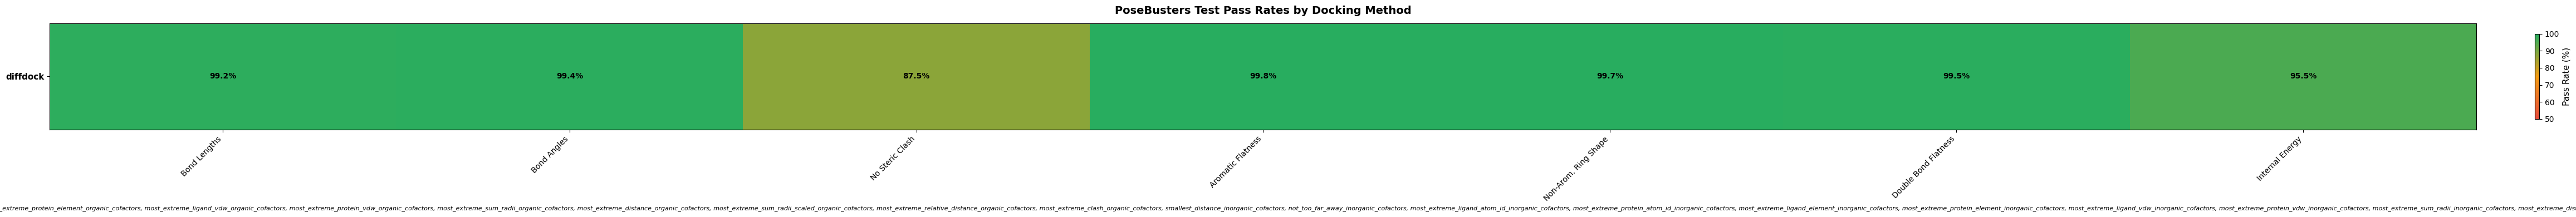

ValueError: Item wrong length 2 instead of 1.

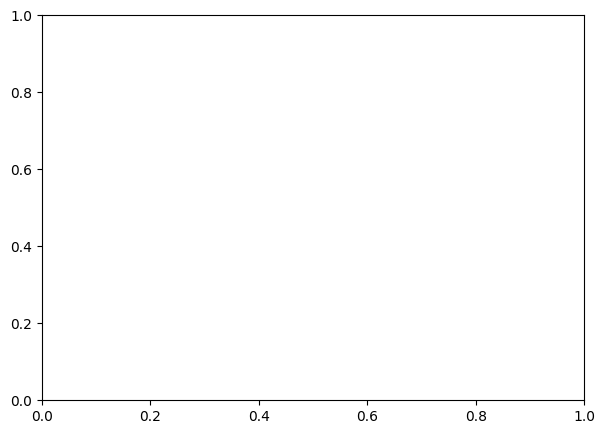

In [10]:
"""
Graphical Representation of PoseBusters Results
=================================================
Comprehensive visualizations of validation test pass rates,
per-method breakdowns, and overall quality profiles.
Methods and colors are derived dynamically from the results.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

# ============================================================================
# LOAD DATA
# ============================================================================
pb_csv = output_dir / "posebusters_filtered_results.csv"
plot_output_dir = output_dir
df = pd.read_csv(pb_csv)

# Identify boolean test columns (same logic as manifest cell)
exclude_cols = {
    'mol_true_loaded', 'mol_cond_loaded',
    'number_short_outlier_bonds', 'number_long_outlier_bonds',
    'number_outlier_angles', 'number_clashes',
    'number_non-aromatic_rings_pass', 'number_aromatic_rings_pass',
    'number_non-aromatic_rings_checked', 'number_aromatic_rings_checked',
    'number_double_bonds_checked', 'number_double_bonds_pass',
    'number_valid_bonds', 'number_valid_angles', 'number_valid_noncov_pairs',
    'number_noncov_pairs', 'number_bonds', 'number_angles',
    'num_h_added',
}
metadata_cols = {
    'file_path', 'filepath', 'file', 'path', 'sdf_file', 'sdf_path',
    'method', 'docking_method', 'protein', 'ligand', 'pose_rank', 'rank',
    'molecule', 'mol_name', 'name', 'complex', 'protein_path', 'ligand_path',
    'mol_pred', 'mol_true', 'mol_cond',
}

test_cols = []
for col in df.columns:
    cl = col.lower().strip()
    if cl in metadata_cols or col in exclude_cols:
        continue
    if cl.startswith('number_') or cl.startswith('num_'):
        continue
    uv = set(df[col].dropna().unique())
    if uv.issubset({True, False, 1, 0, 1.0, 0.0, 'True', 'False', 'true', 'false'}):
        test_cols.append(col)

for tc in test_cols:
    if df[tc].dtype == object:
        df[tc] = df[tc].map({'True': True, 'true': True, 'False': False, 'false': False})
    df[tc] = df[tc].astype(bool)

df["all_passed"] = df[test_cols].all(axis=1)

# Friendly display names for tests
TEST_DISPLAY = {
    'mol_pred_loaded': 'Molecule Loaded',
    'sanitization': 'Sanitization',
    'inchi_convertible': 'InChI Convertible',
    'all_atoms_connected': 'All Atoms Connected',
    'no_radicals': 'No Radicals',
    'bond_lengths': 'Bond Lengths',
    'bond_angles': 'Bond Angles',
    'internal_steric_clash': 'No Steric Clash',
    'aromatic_ring_flatness': 'Aromatic Flatness',
    'non-aromatic_ring_non-flatness': 'Non-Arom. Ring Shape',
    'double_bond_flatness': 'Double Bond Flatness',
    'internal_energy': 'Internal Energy',
    'passes_valence_checks': 'Valence Checks',
    'passes_kekulization': 'Kekulization',
    'no_radicals_before_sanitization': 'No Pre-Sanit. Radicals',
}

# Generate colors dynamically for all methods found in the data
_COLOR_PALETTE = [
    '#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12',
    '#1abc9c', '#e67e22', '#34495e', '#d35400', '#8e44ad',
]

methods = sorted(df['docking_method'].unique())
METHOD_COLORS = {m: _COLOR_PALETTE[i % len(_COLOR_PALETTE)] for i, m in enumerate(methods)}

n_total = len(df)
n_passed = df['all_passed'].sum()

print(f"PoseBusters Results: {n_total} total poses, {n_passed} passed all tests ({n_passed/n_total*100:.1f}%)")
for m in methods:
    g = df[df['docking_method'] == m]
    print(f"  {m}: {g['all_passed'].sum()}/{len(g)} passed ({g['all_passed'].mean()*100:.1f}%)")

# ============================================================================
# FIGURE 1: Overall pass rate heatmap (methods × tests)
# ============================================================================
variable_tests = [t for t in test_cols if df[t].mean() < 1.0]
trivial_tests = [t for t in test_cols if t not in variable_tests]

pass_rates = df.groupby('docking_method')[test_cols].mean() * 100
pass_rates_var = pass_rates[variable_tests] if variable_tests else pass_rates

fig1, ax1 = plt.subplots(figsize=(max(10, len(test_cols) * 0.8), max(4, len(methods) * 0.8)))

cmap = LinearSegmentedColormap.from_list('ryg', ['#e74c3c', '#f39c12', '#27ae60'])

im = ax1.imshow(pass_rates_var.values, cmap=cmap, aspect='auto', vmin=50, vmax=100)

ax1.set_yticks(range(len(pass_rates_var.index)))
ax1.set_yticklabels(pass_rates_var.index, fontsize=11, fontweight='bold')
ax1.set_xticks(range(len(pass_rates_var.columns)))
xlabels = [TEST_DISPLAY.get(c, c.replace('_', ' ').title()) for c in pass_rates_var.columns]
ax1.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=10)

for i in range(pass_rates_var.shape[0]):
    for j in range(pass_rates_var.shape[1]):
        val = pass_rates_var.values[i, j]
        color = 'white' if val < 75 else 'black'
        ax1.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=10,
                fontweight='bold', color=color)

cbar = plt.colorbar(im, ax=ax1, shrink=0.8, pad=0.02)
cbar.set_label('Pass Rate (%)', fontsize=11)

if trivial_tests:
    trivial_str = ', '.join(TEST_DISPLAY.get(t, t) for t in trivial_tests)
    ax1.set_xlabel(f'Tests at 100% (not shown): {trivial_str}', fontsize=8, style='italic')

ax1.set_title('PoseBusters Test Pass Rates by Docking Method', fontsize=14, fontweight='bold', pad=12)
fig1.tight_layout()
fig1.savefig(plot_output_dir / "pb_passrate_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 2: Stacked bar — pass / fail counts per method
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(max(7, len(methods) * 2), 5))

counts = df.groupby('docking_method')['all_passed'].value_counts().unstack(fill_value=0)
if True not in counts.columns:
    counts[True] = 0
if False not in counts.columns:
    counts[False] = 0
counts = counts[[True, False]].rename(columns={True: 'Passed All', False: 'Failed ≥1'})

bars_pass = ax2.bar(range(len(counts)), counts['Passed All'],
                    color=[METHOD_COLORS.get(m, '#888') for m in counts.index],
                    edgecolor='white', linewidth=1.5, label='Passed All Tests')
bars_fail = ax2.bar(range(len(counts)), counts['Failed ≥1'],
                    bottom=counts['Passed All'],
                    color=[METHOD_COLORS.get(m, '#888') for m in counts.index],
                    alpha=0.3, edgecolor='white', linewidth=1.5, hatch='///',
                    label='Failed ≥1 Test')

for i, (m, row) in enumerate(counts.iterrows()):
    total = row.sum()
    pct = row['Passed All'] / total * 100
    ax2.text(i, total + 5, f'{int(row["Passed All"])}/{int(total)}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_xticks(range(len(counts)))
ax2.set_xticklabels(counts.index, fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Poses', fontsize=12)
ax2.set_title('PoseBusters Validation Summary by Docking Method', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.set_ylim(0, counts.sum(axis=1).max() * 1.25)
ax2.grid(axis='y', alpha=0.3)
fig2.tight_layout()
fig2.savefig(plot_output_dir / "pb_pass_fail_bars.png", dpi=200, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 3: Per-test failure rate comparison (grouped bar chart)
# ============================================================================
if variable_tests:
    fail_rates = (1 - df.groupby('docking_method')[variable_tests].mean()) * 100

    fig3, ax3 = plt.subplots(figsize=(max(10, len(variable_tests) * 1.5), 5))

    x = np.arange(len(variable_tests))
    width = 0.8 / len(methods)

    for i, m in enumerate(methods):
        vals = fail_rates.loc[m].values
        bars = ax3.bar(x + i * width - 0.4 + width / 2, vals, width,
                       label=m, color=METHOD_COLORS.get(m, '#888'), edgecolor='white')
        for j, v in enumerate(vals):
            if v > 2:
                ax3.text(x[j] + i * width - 0.4 + width / 2, v + 0.5,
                         f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax3.set_xticks(x)
    xlabels3 = [TEST_DISPLAY.get(c, c.replace('_', ' ').title()) for c in variable_tests]
    ax3.set_xticklabels(xlabels3, rotation=40, ha='right', fontsize=10)
    ax3.set_ylabel('Failure Rate (%)', fontsize=12)
    ax3.set_title('PoseBusters Failure Rates by Test and Method', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(axis='y', alpha=0.3)
    fig3.tight_layout()
    fig3.savefig(plot_output_dir / "pb_failure_rates.png", dpi=200, bbox_inches='tight')
    plt.show()

# ============================================================================
# FIGURE 4: Per protein-ligand pass rate (faceted by method)
# ============================================================================
n_methods = len(methods)
fig4, axes4 = plt.subplots(1, n_methods, figsize=(6 * n_methods, 5), sharey=True,
                            squeeze=False)
axes4 = axes4.flatten()

for ax, m in zip(axes4, methods):
    sub = df[df['docking_method'] == m]
    combo_pass = sub.groupby(['protein', 'ligand'])['all_passed'].mean() * 100
    combo_pass = combo_pass.sort_values(ascending=True)

    labels = [f'{p}\n{l}' for p, l in combo_pass.index]
    colors = [('#27ae60' if v >= 75 else '#f39c12' if v >= 50 else '#e74c3c') for v in combo_pass.values]

    ax.barh(range(len(combo_pass)), combo_pass.values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(combo_pass)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Pass Rate (%)', fontsize=11)
    ax.set_title(m, fontsize=13, fontweight='bold', color=METHOD_COLORS.get(m, 'black'))
    ax.set_xlim(0, 105)
    ax.axvline(75, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='x', alpha=0.3)

    for i, v in enumerate(combo_pass.values):
        ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)

fig4.suptitle('PoseBusters Pass Rate by Protein–Ligand Combination', fontsize=14, fontweight='bold')
fig4.tight_layout()
fig4.savefig(plot_output_dir / "pb_pass_by_combo.png", dpi=200, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 5: Number of tests failed distribution (violin + strip)
# ============================================================================
df['n_failed'] = df[test_cols].apply(lambda row: (~row).sum(), axis=1)

fig5, ax5 = plt.subplots(figsize=(max(8, len(methods) * 2.5), 5))

for i, m in enumerate(methods):
    vals = df[df['docking_method'] == m]['n_failed']
    parts = ax5.violinplot([vals], positions=[i], showmedians=True, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor(METHOD_COLORS.get(m, '#888'))
        pc.set_alpha(0.4)
    for key in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
        parts[key].set_color(METHOD_COLORS.get(m, '#888'))
    jitter = np.random.normal(0, 0.08, len(vals))
    ax5.scatter(np.full(len(vals), i) + jitter, vals, s=10, alpha=0.3,
                color=METHOD_COLORS.get(m, '#888'))

ax5.set_xticks(range(len(methods)))
ax5.set_xticklabels(methods, fontsize=12, fontweight='bold')
ax5.set_ylabel('Number of Tests Failed', fontsize=12)
ax5.set_title('Distribution of Failed Tests per Pose', fontsize=14, fontweight='bold')
ax5.set_ylim(-0.5, df['n_failed'].max() + 1)
ax5.grid(axis='y', alpha=0.3)

for i, m in enumerate(methods):
    med = df[df['docking_method'] == m]['n_failed'].median()
    ax5.text(i, med + 0.3, f'median={med:.0f}', ha='center', fontsize=9, fontweight='bold')

fig5.tight_layout()
fig5.savefig(plot_output_dir / "pb_nfailed_violin.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"\nAll figures saved to: {plot_output_dir}")
print("  pb_passrate_heatmap.png  — Test pass rate heatmap (methods × tests)")
print("  pb_pass_fail_bars.png    — Pass/fail stacked bars per method")
print("  pb_failure_rates.png     — Per-test failure rates (grouped bars)")
print("  pb_pass_by_combo.png     — Pass rate by protein–ligand combination")
print("  pb_nfailed_violin.png    — Distribution of #tests failed per pose")